Enter full path to Excel file: C:\Users\cugli\Desktop\冀东数据处理后结果\majorID.xlsx

Enter column index/name for [Lithology]: 5

Enter column index/name for [Analyzed Material]: 6


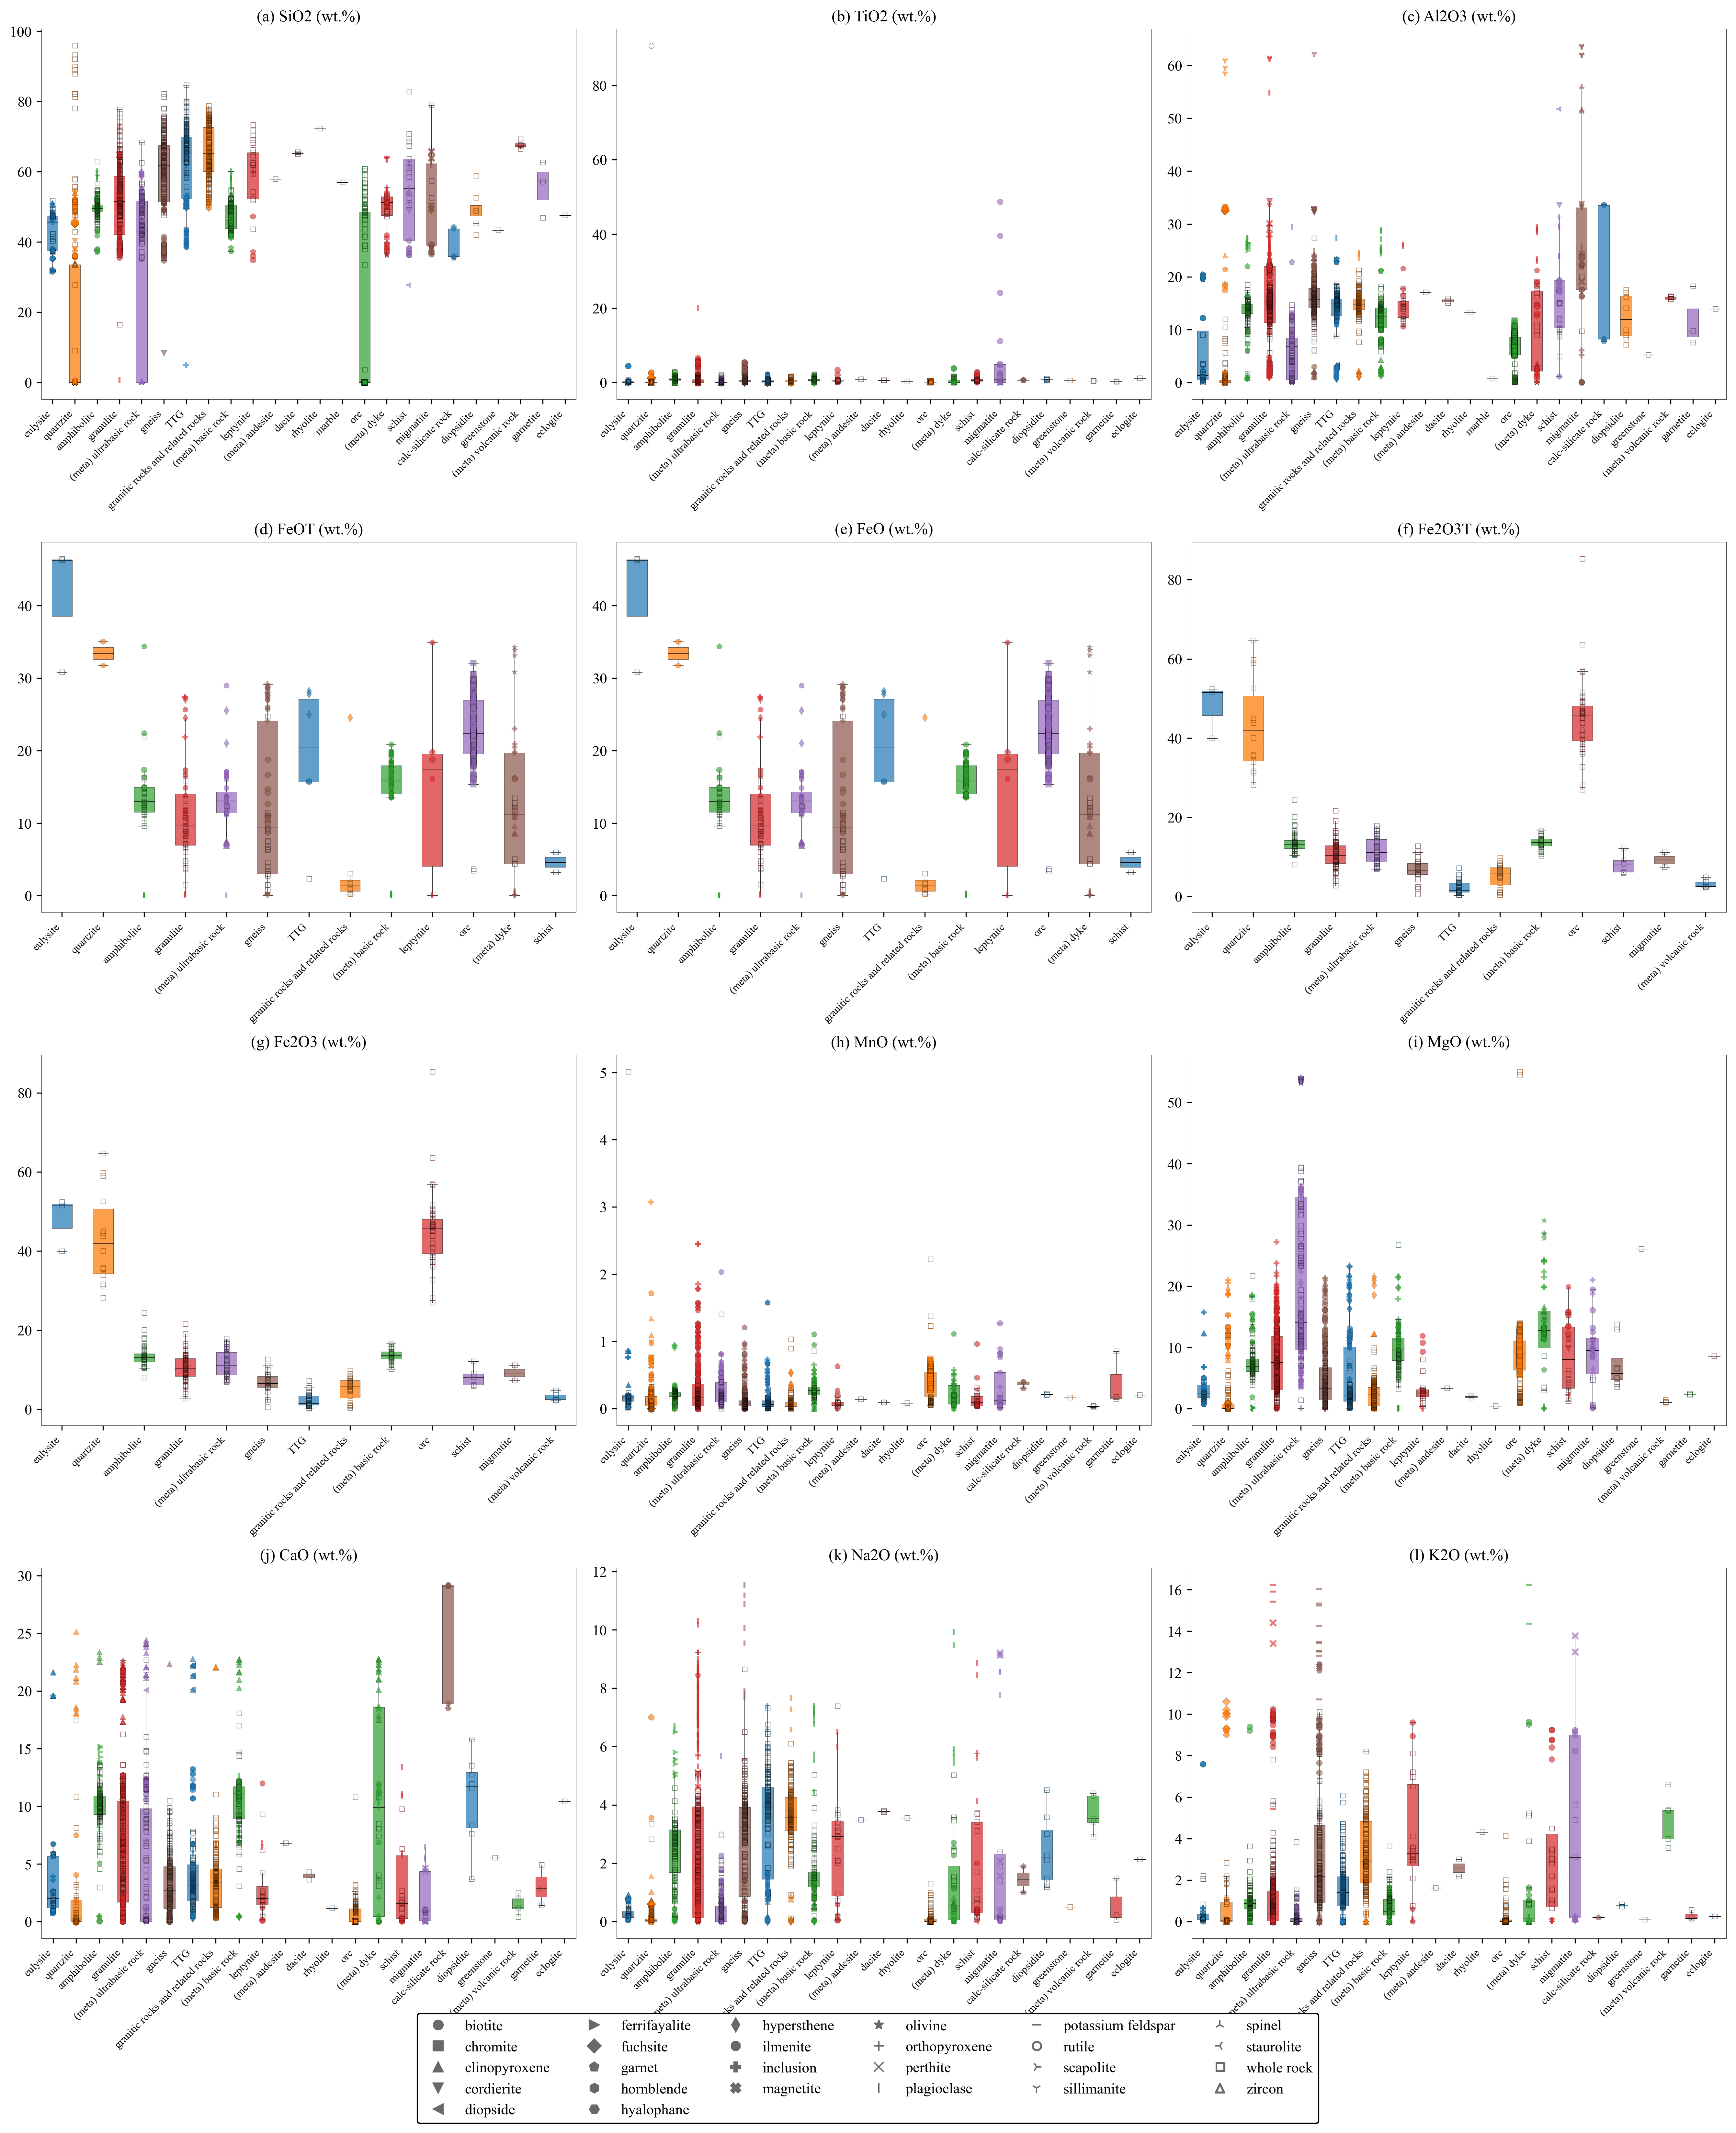


🎉 Saved successfully!
📁 File location: C:\Users\cugli\Desktop\冀东数据处理后结果\jupyter
✅ Legend at bottom ✅ Bordered ✅ Wrapped ✅ Uniform width


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from pathlib import Path
from matplotlib.lines import Line2D
import warnings

# Suppress all warnings completely
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None
np.seterr(all='ignore')

# ====================== Plot Settings ======================
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.linewidth": 0.2,
    "figure.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.format": "svg",
    "axes.unicode_minus": False,
    "figure.autolayout": False
})

# ====================== 26 Mineral Markers ======================
marker_map = {
    "biotite": "o",
    "chromite": "s",
    "clinopyroxene": "^",
    "cordierite": "v",
    "diopside": "<",
    "ferrifayalite": ">",
    "fuchsite": "D",
    "garnet": "p",
    "hornblende": "h",
    "hyalophane": "H",
    "hypersthene": "d",
    "ilmenite": "8",
    "inclusion": "P",
    "magnetite": "X",
    "olivine": "*",
    "orthopyroxene": "+",
    "perthite": "x",
    "plagioclase": "|",
    "potassium feldspar": "_",
    "rutile": "$\u25EF$",
    "scapolite": "4",
    "sillimanite": "1",
    "spinel": "2",
    "staurolite": "3",
    "whole rock": "$\u25A1$",
    "zircon": "$\u25B3$"
}

# ====================== Filled Marker Check ======================
def is_filled_marker(marker):
    unfilled = ['+', 'x', '|', '_', '1', '2', '3', '4', 'P']
    return marker not in unfilled

# ====================== Fuzzy Column Matching ======================
def fuzzy_match_column(df, target_name):
    for col in df.columns:
        clean_col = re.sub(r'[\s\(\)w.t%₂_]', '', str(col).lower())
        clean_target = re.sub(r'[\s\(\)w.t%₂_]', '', target_name.lower())
        if clean_col == clean_target:
            return col
    return None

# ====================== Data Loading ======================
def load_data():
    excel_path = input("Enter full path to Excel file: ").strip().replace('"','')
    
    while True:
        if os.path.exists(excel_path) and excel_path.endswith(".xlsx"):
            break
        print("❌ Invalid file, please re-enter")
        excel_path = input("Enter full path to Excel file: ").strip().replace('"','')

    df = pd.read_excel(excel_path)
    
    while True:
        litho_input = input("\nEnter column index/name for [Lithology]: ").strip()
        try:
            if litho_input.isdigit():
                litho_col = df.columns[int(litho_input)-1]
            else:
                litho_col = litho_input
            if litho_col in df.columns:
                break
            else:
                print("❌ Column not found, please re-enter")
        except:
            print("❌ Invalid input format, please re-enter")

    while True:
        mat_input = input("\nEnter column index/name for [Analyzed Material]: ").strip()
        try:
            if mat_input.isdigit():
                mat_col = df.columns[int(mat_input)-1]
            else:
                mat_col = mat_input
            if mat_col in df.columns:
                break
            else:
                print("❌ Column not found, please re-enter")
        except:
            print("❌ Invalid input format, please re-enter")

    target_elements = [
        "SiO2", "TiO2", "Al2O3", "FeOT", "FeO", "Fe2O3T", "Fe2O3",
        "MnO", "MgO", "CaO", "Na2O", "K2O"
    ]

    valid_data = {}
    for elem in target_elements:
        col = fuzzy_match_column(df, elem)
        if col:
            valid_data[elem] = pd.to_numeric(df[col], errors='coerce')

    plot_df = pd.DataFrame(valid_data)
    plot_df[litho_col] = df[litho_col]
    plot_df[mat_col] = df[mat_col]
    
    return plot_df, litho_col, mat_col, list(valid_data.keys())

# ====================== Boxplot Function ======================
def plot_boxplot(df, litho_col, mat_col, elements):
    n_elements = len(elements)
    cols = 3
    rows = (n_elements + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5.5))
    axes = axes.flatten()

    colors = ["#1f77b4", "#ff7700", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    litho_types = df[litho_col].dropna().unique()
    mat_types = np.unique(df[mat_col].dropna())

    for idx, elem in enumerate(elements):
        ax = axes[idx]
        data = df.dropna(subset=[elem, litho_col, mat_col])

        box_data, labels = [], []
        for i, lt in enumerate(litho_types):
            sub = data[data[litho_col] == lt]
            if len(sub) > 0:
                box_data.append(sub[elem].values)
                labels.append(lt)

        if box_data:
            bp = ax.boxplot(
                box_data,
                patch_artist=True,
                showfliers=False,
                boxprops=dict(linewidth=0.2),
                whiskerprops=dict(linewidth=0.2),
                capprops=dict(linewidth=0.2),
                medianprops=dict(linewidth=0.3, color='black')
            )
            
            for i, patch in enumerate(bp["boxes"]):
                patch.set_facecolor(colors[i % len(colors)])
                patch.set_alpha(0.7)

            ax.set_xticklabels(labels)

            for mt in mat_types:
                if mt not in marker_map:
                    continue
                marker = marker_map[mt]
                filled = is_filled_marker(marker)

                for li, lt in enumerate(labels):
                    s = data[(data[litho_col]==lt) & (data[mat_col]==mt)]
                    if len(s) == 0:
                        continue

                    scatter_kwargs = {
                        "marker": marker, "color": colors[li % len(colors)],
                        "s": 20, "alpha": 0.6, "zorder": 3
                    }
                    if filled:
                        scatter_kwargs["edgecolor"] = "black"
                        scatter_kwargs["linewidth"] = 0.1

                    ax.scatter([li+1]*len(s), s[elem], **scatter_kwargs)

        ax.set_title(f"({chr(97+idx)}) {elem} (wt.%)", fontsize=12)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        plt.setp(ax.get_xticklabels(), ha="right")

    for i in range(len(elements), len(axes)):
        axes[i].set_visible(False)

    legend_elements = [
        Line2D([0], [0], marker=marker_map[mt], color='dimgray',
               linestyle='', markersize=7, label=mt)
        for mt in mat_types if mt in marker_map
    ]

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, 0),
        ncol=6,
        frameon=True,
        framealpha=1,
        edgecolor='black'
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.09)

    save_path = Path.cwd() / "major_element_boxplot_FINAL"
    plt.savefig(f"{save_path}.svg", bbox_inches='tight')
    plt.savefig(f"{save_path}.jpg", bbox_inches='tight', dpi=300)
    
    plt.show()
    plt.close()

    print("\n🎉 Saved successfully!")
    print(f"📁 File location: {save_path.parent}")
    print("✅ Legend at bottom ✅ Bordered ✅ Wrapped ✅ Uniform width")

# ====================== Main Program ======================
if __name__ == "__main__":
    # Load data
    plot_df, litho_col, mat_col, valid_elements = load_data()
    # Plot
    plot_boxplot(plot_df, litho_col, mat_col, valid_elements)